# Debug Sentinel Values in aFRR Prices

Investigate `±99999.99` placeholders in `afrr_activation_price_pos/neg` and propose a cleaning rule.

In [4]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

processed = Path('data/processed/all_data.parquet')
raw = Path('data/raw/all_data.parquet')

if processed.exists():
    data_path = processed
elif raw.exists():
    data_path = raw
else:
    raise FileNotFoundError('Neither data/processed/all_data.parquet nor data/raw/all_data.parquet found')

df = pl.read_parquet(data_path)
df.shape

(44545, 70)

## Investigation: Positive Direction (price_pos > 10000)

In [5]:
needed_pos = {'afrr_activation_price_pos', 'afrr_activated_mw_pos'}
missing = needed_pos - set(df.columns)
if missing:
    raise KeyError(f'Missing columns: {sorted(missing)}')

pos_sentinel = df.filter(pl.col('afrr_activation_price_pos') > 10000)
pos_count = pos_sentinel.height
pos_count

32651

In [6]:
# Volume stats for positive sentinel rows
pos_stats = pos_sentinel.select(['afrr_activated_mw_pos']).describe()
pos_stats

statistic,afrr_activated_mw_pos
str,f64
"""count""",32650.0
"""null_count""",1.0
"""mean""",19.283876
"""std""",31.757498
"""min""",0.0
"""25%""",0.668
"""50%""",4.91
"""75%""",24.86
"""max""",637.038


In [7]:
# How many have volume == 0?
pos_zero = pos_sentinel.filter(pl.col('afrr_activated_mw_pos') == 0).height
print(f'Found {pos_count} rows with price_pos > 10000; volume == 0 in {pos_zero} rows.')

Found 32651 rows with price_pos > 10000; volume == 0 in 2758 rows.


## Investigation: Negative Direction (price_neg < -10000)

In [8]:
needed_neg = {'afrr_activation_price_neg', 'afrr_activated_mw_neg'}
missing = needed_neg - set(df.columns)
if missing:
    raise KeyError(f'Missing columns: {sorted(missing)}')

neg_sentinel = df.filter(pl.col('afrr_activation_price_neg') < -10000)
neg_count = neg_sentinel.height
neg_count

31113

In [9]:
# Volume stats for negative sentinel rows
neg_stats = neg_sentinel.select(['afrr_activated_mw_neg']).describe()
neg_stats

statistic,afrr_activated_mw_neg
str,f64
"""count""",31113.0
"""null_count""",0.0
"""mean""",21.551377
"""std""",32.522019
"""min""",0.0
"""25%""",0.972
"""50%""",6.254
"""75%""",30.278
"""max""",605.556


In [10]:
# How many have volume == 0?
neg_zero = neg_sentinel.filter(pl.col('afrr_activated_mw_neg') == 0).height
print(f'Found {neg_count} rows with price_neg < -10000; volume == 0 in {neg_zero} rows.')

Found 31113 rows with price_neg < -10000; volume == 0 in 1983 rows.


## Visualization

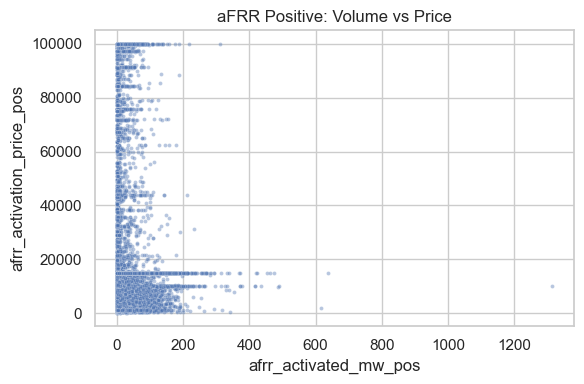

In [11]:
# Scatter: volume vs price (positive)
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=df['afrr_activated_mw_pos'].to_numpy(),
    y=df['afrr_activation_price_pos'].to_numpy(),
    s=8,
    alpha=0.4,
)
plt.title('aFRR Positive: Volume vs Price')
plt.xlabel('afrr_activated_mw_pos')
plt.ylabel('afrr_activation_price_pos')
plt.tight_layout()

## Proposed Fix (Polars Snippet)

In [12]:
# Replace sentinel values with nulls
cleaned = df.with_columns([
    pl.when(pl.col('afrr_activation_price_pos').abs() >= 99999)
      .then(None)
      .otherwise(pl.col('afrr_activation_price_pos'))
      .alias('afrr_activation_price_pos'),
    pl.when(pl.col('afrr_activation_price_neg').abs() >= 99999)
      .then(None)
      .otherwise(pl.col('afrr_activation_price_neg'))
      .alias('afrr_activation_price_neg'),
])

# Optional: interpolate where volume != 0 but price is null
cleaned = cleaned.with_columns([
    pl.when((pl.col('afrr_activation_price_pos').is_null()) & (pl.col('afrr_activated_mw_pos') != 0))
      .then(pl.col('afrr_activation_price_pos').interpolate())
      .otherwise(pl.col('afrr_activation_price_pos'))
      .alias('afrr_activation_price_pos'),
    pl.when((pl.col('afrr_activation_price_neg').is_null()) & (pl.col('afrr_activated_mw_neg') != 0))
      .then(pl.col('afrr_activation_price_neg').interpolate())
      .otherwise(pl.col('afrr_activation_price_neg'))
      .alias('afrr_activation_price_neg'),
])

cleaned.select(['afrr_activation_price_pos', 'afrr_activation_price_neg']).head()

afrr_activation_price_pos,afrr_activation_price_neg
f64,f64
23800.0,-5999.0
23800.0,-5999.0
23800.0,-5999.0
11519.16,-5988.23
11519.16,-5977.46


## Execution Summary

In [13]:
print(f'Found {pos_count} rows with price_pos > 10000; volume == 0 in {pos_zero} rows.')
print(f'Found {neg_count} rows with price_neg < -10000; volume == 0 in {neg_zero} rows.')

Found 32651 rows with price_pos > 10000; volume == 0 in 2758 rows.
Found 31113 rows with price_neg < -10000; volume == 0 in 1983 rows.
